# Main figure 4: amplitude robustness

This notebook compares the complete measured echo-root-Lorentzian sweep with parameter-matched ordinary root-Lorentzian and echo-root-Lorentzian two-level Lindblad simulations, together with the analytic constant-drive reference. The simulations use the saved pulse length, cutoff, peak-output calibration, amplitude grid, and detuning grid together with the measurement-linked coherence parameters. The measured and simulated echo data pass through the same operational Gaussian estimator and quality gates; the ordinary root-Lorentzian peak is analyzed with the corresponding sign-reversed estimator. The cyclic-frequency FWHM $\Gamma_f$ is normalized to the conservative measured-coherence reference $\Gamma_{f,T_2}=1/(\pi T_{2,\mathrm{eff}})$, and resolution is normalized to its reciprocal. Failed quality gates remain missing values; they are never converted into zero-width results.

In [1]:
from pathlib import Path
import json
import os
import re
import sys

PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'echospec').is_dir())
os.environ.setdefault('MPLCONFIGDIR', str(PROJECT_ROOT / '.codex_tmp' / 'mpl'))
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from scipy.ndimage import gaussian_filter1d
from scipy.optimize import curve_fit

from echospec.figures import FigureVariant, apply_figure_style, save_figure
from echospec.simulation.pulses import PulseArgs, PulseType, choose_pulse
from echospec.simulation.run import Options, Solver
from echospec.utils.parameters import Parameters
from echospec.utils.units import Units as u

VARIANT = FigureVariant.PAPER
apply_figure_style(VARIANT)

DATA_PATH = PROJECT_ROOT / 'ips_plots/data/lorentzian_echo/echo_lorentzian_12-33-44-667799_data_bundle.npz'
EDGE_POINTS = 40
SMOOTH_SIGMA_POINTS = 1.0
INITIAL_SIGMA_MHZ = 0.040
MIN_CONTRAST = 0.02
MAX_FWHM_MHZ = 0.12
MAX_ABS_CENTER_MHZ = 0.050
SIMULATION_TIME_STEPS = 2000

COHERENCE_PARAMETERS_PATH = PROJECT_ROOT / 'paper' / 'coherence_parameters.tex'
coherence_text = COHERENCE_PARAMETERS_PATH.read_text()

def latex_macro_float(name):
    match = re.search(rf'\\newcommand\{{\\{name}\}}\{{([0-9.]+)', coherence_text)
    if match is None:
        raise ValueError(f'Missing numeric macro {name} in {COHERENCE_PARAMETERS_PATH}')
    return float(match.group(1))

T1_US = latex_macro_float('MeasuredTOne')
T2_EFFECTIVE_US = latex_macro_float('EffectiveTTwo')
TPHI_US = latex_macro_float('EffectiveTPhi')
T2_LIMIT_FWHM_KHZ = latex_macro_float('EffectiveCoherenceFwhm')
T2_LIMIT_FWHM_MHZ = T2_LIMIT_FWHM_KHZ / 1e3
print(
    f'Using T1={T1_US:.2f} us, Tphi={TPHI_US:.2f} us, '
    f'T2_eff={T2_EFFECTIVE_US:.2f} us, and Gamma_T2={T2_LIMIT_FWHM_KHZ:.1f} kHz.'
)

Using T1=51.24 us, Tphi=7.87 us, T2_eff=7.31 us, and Gamma_T2=43.5 kHz.


In [2]:
def load_amplitude_sweep(path):
    with np.load(path, allow_pickle=True) as bundle:
        qubits = json.loads(bundle['profile__qubits.json'].item())['qubits']
        pulses = json.loads(bundle['profile__pulses.json'].item())['pulses']
        settings = json.loads(bundle['parameters.json'].item())
        qubit = str(bundle['data__qubit'][0])
        x180_name = qubits[qubit]['operations']['x180']
        pi_pulse = pulses[qubit][x180_name]
        amp_prefactor = np.asarray(bundle['data__amp_prefactor'], dtype=float)
        pi_rabi_mhz = 1000 / (2 * pi_pulse['length_ns'])
        peak_output_amplitude = float(settings['lorentzian_peak_amplitude'])
        rabi_mhz = (
            amp_prefactor * peak_output_amplitude
            / pi_pulse['amplitude'] * pi_rabi_mhz
        )
        acquisition = {
            'pulse_shape': str(settings['pulse_shape']),
            'pulse_length_us': float(settings['lorentzian_length_in_ns']) / 1000,
            'cutoff': float(settings['cutoff']),
            'echo': bool(settings['echo']),
            'peak_output_amplitude': peak_output_amplitude,
            'x180_amplitude': float(pi_pulse['amplitude']),
            'x180_length_ns': float(pi_pulse['length_ns']),
        }
        return (
            np.asarray(bundle['data__detuning'], dtype=float) / 1e6,
            rabi_mhz,
            np.asarray(bundle['data__state'][0], dtype=float),
            qubit,
            acquisition,
        )

def dip_gaussian(detuning_mhz, offset, depth, center_mhz, sigma_mhz):
    return offset - depth * np.exp(-0.5 * ((detuning_mhz - center_mhz) / sigma_mhz) ** 2)

detuning_mhz, rabi_mhz, state, qubit, acquisition = load_amplitude_sweep(DATA_PATH)
print(
    f"Loaded {state.shape[1]} amplitude slices for {qubit}: "
    f"{acquisition['pulse_shape']}, L={acquisition['pulse_length_us']:g} us, "
    f"c={acquisition['cutoff']:g}, echo={acquisition['echo']}, "
    f"peak output={acquisition['peak_output_amplitude']:g}."
)

def simulate_bloch_grid(
    detuning_mhz,
    rabi_mhz,
    *,
    pulse_length_us,
    cutoff,
    echo,
    T1_us,
    Tphi_us,
    num_time_steps,
    pulse_type=PulseType.LORENTZIAN,
):
    """Vectorized two-level Lindblad evolution on the acquisition grid."""
    pulse_length_s = pulse_length_us * 1e-6
    T1_s = T1_us * 1e-6
    Tphi_s = Tphi_us * 1e-6
    T2_s = 1 / (1 / Tphi_s + 1 / (2 * T1_s))
    detuning_rad_s = 2 * np.pi * np.asarray(detuning_mhz)[None, :] * 1e6
    peak_rabi_rad_s = 2 * np.pi * np.asarray(rabi_mhz)[:, None] * 1e6
    shape = (len(rabi_mhz), len(detuning_mhz))
    x = np.zeros(shape, dtype=float)
    y = np.zeros(shape, dtype=float)
    z = np.ones(shape, dtype=float)

    dt = pulse_length_s / num_time_steps
    time_midpoints = (
        -pulse_length_s / 2
        + (np.arange(num_time_steps, dtype=float) + 0.5) * dt
    )
    pulse = choose_pulse(pulse_type, echo)
    pulse_args = PulseArgs(
        pulse_length=pulse_length_s, cutoff=cutoff, order=0.5, zeroed_pulse=False
    )
    envelope = (
        np.ones_like(time_midpoints)
        if pulse is None
        else pulse(time_midpoints, pulse_args)
    )

    def derivatives(x_value, y_value, z_value, omega_rad_s):
        return (
            detuning_rad_s * y_value - x_value / T2_s,
            -detuning_rad_s * x_value - omega_rad_s * z_value - y_value / T2_s,
            omega_rad_s * y_value + (1 - z_value) / T1_s,
        )

    for envelope_value in envelope:
        omega = peak_rabi_rad_s * envelope_value
        k1 = derivatives(x, y, z, omega)
        k2 = derivatives(
            x + dt * k1[0] / 2, y + dt * k1[1] / 2, z + dt * k1[2] / 2, omega
        )
        k3 = derivatives(
            x + dt * k2[0] / 2, y + dt * k2[1] / 2, z + dt * k2[2] / 2, omega
        )
        k4 = derivatives(
            x + dt * k3[0], y + dt * k3[1], z + dt * k3[2], omega
        )
        x += dt * (k1[0] + 2 * k2[0] + 2 * k3[0] + k4[0]) / 6
        y += dt * (k1[1] + 2 * k2[1] + 2 * k3[1] + k4[1]) / 6
        z += dt * (k1[2] + 2 * k2[2] + 2 * k3[2] + k4[2]) / 6

    return ((1 - z) / 2).T

simulated_state = simulate_bloch_grid(
    detuning_mhz,
    rabi_mhz,
    pulse_length_us=acquisition['pulse_length_us'],
    cutoff=acquisition['cutoff'],
    echo=acquisition['echo'],
    T1_us=T1_US,
    Tphi_us=TPHI_US,
    num_time_steps=SIMULATION_TIME_STEPS,
)
print(f'Simulated the matched {simulated_state.shape} detuning-amplitude grid.')

spot_check_errors = []
for amplitude_index, detuning_index in [(33, 500), (66, 600), (99, 400)]:
    params = Parameters(
        T1=T1_US * u.us,
        T_dephasing=TPHI_US * u.us,
        pulse_type=PulseType.LORENTZIAN,
        eco_pulse=acquisition['echo'],
        pulse_length=acquisition['pulse_length_us'] * u.us,
        cutoff=acquisition['cutoff'],
        rabi_frequency=rabi_mhz[amplitude_index] * u.pi2 * u.MHz,
        detuning=detuning_mhz[detuning_index] * u.pi2 * u.MHz,
    )
    qutip_result = Solver(params, Options(num_time_points=1001)).run()
    qutip_population = (1 - qutip_result.final_z) / 2
    spot_check_errors.append(
        abs(simulated_state[detuning_index, amplitude_index] - qutip_population)
    )
max_spot_check_error = max(spot_check_errors)
assert max_spot_check_error < 2e-4
print(f'RK4/QuTiP spot-check max |delta P1| = {max_spot_check_error:.2e}.')

Loaded 100 amplitude slices for q1: root_lorentzian, L=10 us, c=0.005, echo=True, peak output=0.2.
Simulated the matched (1001, 100) detuning-amplitude grid.
RK4/QuTiP spot-check max |delta P1| = 4.40e-05.


<!-- Prepare the constant-pulse reference grid before the extracted-metric cells. -->

In [3]:
# Constant-drive metrics are evaluated with the Torrey tool below.


## Full two-dimensional sweeps

The measured and simulated excited-state populations are shown on the same calibrated peak-Rabi and detuning axes with a shared color scale.

[PosixPath('/Users/asafsolonnikov/Developer/amplitude-robust-spectroscopy/figures/paper/03_amplitude_robustness_2d.pdf'),
 PosixPath('/Users/asafsolonnikov/Developer/amplitude-robust-spectroscopy/figures/paper/03_amplitude_robustness_2d.png'),
 PosixPath('/Users/asafsolonnikov/Developer/amplitude-robust-spectroscopy/figures/paper/03_amplitude_robustness_2d.svg')]

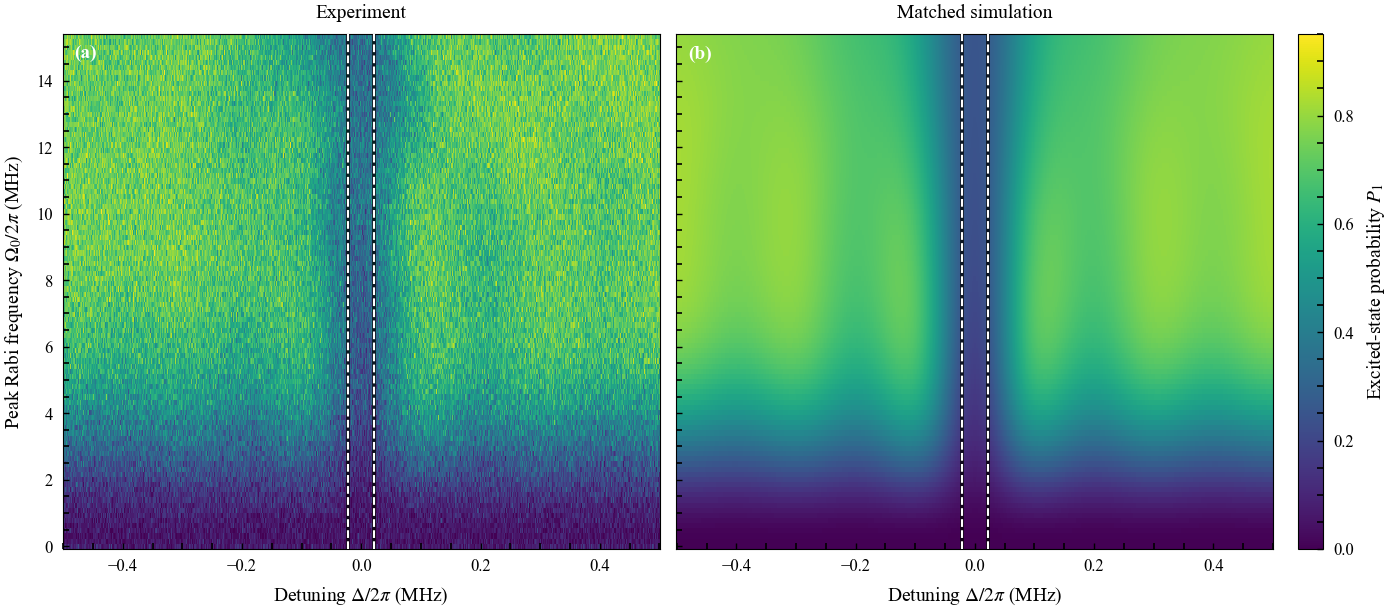

In [4]:
map_vmin = 0.0
map_vmax = float(np.nanmax([state, simulated_state]))
fig_maps, map_axes = plt.subplots(
    1, 2, figsize=(7.0, 3.1), sharex=True, sharey=True, constrained_layout=True
)

for panel, ax, title, traces in zip(
    ['(a)', '(b)'],
    map_axes,
    ['Experiment', 'Matched simulation'],
    [state, simulated_state],
):
    image = ax.pcolormesh(
        detuning_mhz, rabi_mhz, traces.T,
        shading='auto', cmap='viridis', vmin=map_vmin, vmax=map_vmax,
        rasterized=True,
    )
    ax.set_title(title)
    ax.set_xlabel(r'Detuning $\Delta/2\pi$ (MHz)')
    for t2_edge_mhz in (-T2_LIMIT_FWHM_MHZ / 2, T2_LIMIT_FWHM_MHZ / 2):
        ax.axvline(
            t2_edge_mhz, color='black', lw=1.4, alpha=0.75, zorder=4,
        )
        ax.axvline(
            t2_edge_mhz, color='white', lw=0.75, ls='--', zorder=5,
        )
    ax.text(
        0.02, 0.98, panel, transform=ax.transAxes,
        ha='left', va='top', color='white', fontweight='bold',
    )

map_axes[0].set_ylabel(r'Peak Rabi frequency $\Omega_0/2\pi$ (MHz)')
colorbar = fig_maps.colorbar(image, ax=map_axes, pad=0.02)
colorbar.set_label(r'Excited-state probability $P_1$')
saved_maps = save_figure(
    fig_maps, '03_amplitude_robustness_2d', variant=VARIANT,
    formats=('pdf', 'png', 'svg'), dpi=300,
)
saved_maps

## Representative fixed-amplitude spectra

Three calibrated amplitudes sample the low-, intermediate-, and high-drive regimes. Experimental points and the parameter-matched simulation are shown without affine readout or frequency-offset fitting.

Selected calibrated amplitudes (MHz): [2.0112 4.9507 8.9731]


[PosixPath('/Users/asafsolonnikov/Developer/amplitude-robust-spectroscopy/figures/paper/03_amplitude_robustness_linecuts.pdf'),
 PosixPath('/Users/asafsolonnikov/Developer/amplitude-robust-spectroscopy/figures/paper/03_amplitude_robustness_linecuts.png'),
 PosixPath('/Users/asafsolonnikov/Developer/amplitude-robust-spectroscopy/figures/paper/03_amplitude_robustness_linecuts.svg')]

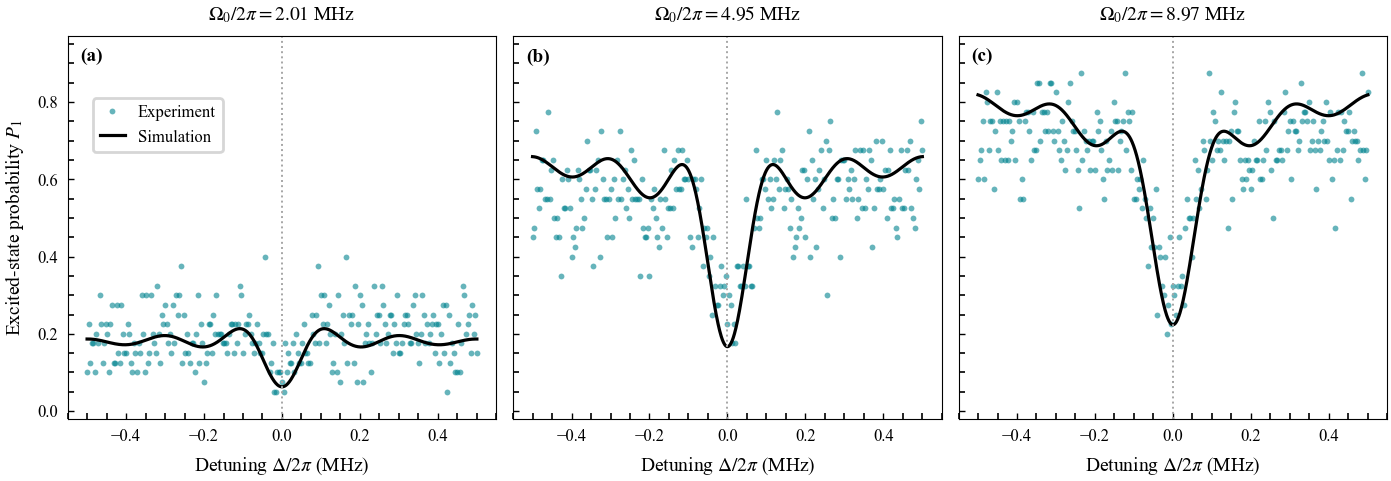

In [5]:
TARGET_LINECUT_RABI_MHZ = np.asarray([2.0, 5.0, 9.0])
linecut_indices = np.asarray([
    int(np.argmin(np.abs(rabi_mhz - target)))
    for target in TARGET_LINECUT_RABI_MHZ
])
selected_linecut_rabi_mhz = rabi_mhz[linecut_indices]

fig_linecuts, linecut_axes = plt.subplots(
    1, 3, figsize=(7.0, 2.45), sharex=True, sharey=True, constrained_layout=True
)
for panel, ax, amplitude_index, amplitude_mhz in zip(
    ['(a)', '(b)', '(c)'],
    linecut_axes,
    linecut_indices,
    selected_linecut_rabi_mhz,
):
    ax.plot(
        detuning_mhz[::4], state[::4, amplitude_index], 'o',
        ms=2.1, mew=0, color='#00838f', alpha=0.60,
        label='Experiment' if panel == '(a)' else None,
    )
    ax.plot(
        detuning_mhz, simulated_state[:, amplitude_index],
        color='black', lw=1.15,
        label='Simulation' if panel == '(a)' else None,
    )
    ax.axvline(0, color='0.65', ls=':', lw=0.7)
    ax.set_title(rf'$\Omega_0/2\pi={amplitude_mhz:.2f}$ MHz')
    ax.set_xlabel(r'Detuning $\Delta/2\pi$ (MHz)')
    ax.text(
        0.03, 0.97, panel, transform=ax.transAxes,
        ha='left', va='top', fontweight='bold',
    )

linecut_axes[0].set_ylabel(r'Excited-state probability $P_1$')
linecut_axes[0].legend(loc='upper left', bbox_to_anchor=(0.04, 0.86))
linecut_axes[0].set_ylim(-0.02, map_vmax + 0.02)
saved_linecuts = save_figure(
    fig_linecuts, '03_amplitude_robustness_linecuts', variant=VARIANT,
    formats=('pdf', 'png', 'svg'), dpi=300,
)
print('Selected calibrated amplitudes (MHz):', np.round(selected_linecut_rabi_mhz, 4))
saved_linecuts

In [6]:
def fit_slice(detuning_mhz, trace):
    x = np.asarray(detuning_mhz[EDGE_POINTS:-EDGE_POINTS], dtype=float)
    y = gaussian_filter1d(np.asarray(trace[EDGE_POINTS:-EDGE_POINTS], dtype=float), SMOOTH_SIGMA_POINTS)
    step = float(np.median(np.diff(x)))
    span = float(x.max() - x.min())
    edge_count = max(5, x.size // 10)
    offset0 = float(np.median(np.r_[y[:edge_count], y[-edge_count:]]))
    minimum_index = int(np.argmin(y))
    depth0 = max(offset0 - float(y[minimum_index]), 1e-3)
    center0 = float(x[minimum_index])

    try:
        values, covariance = curve_fit(
            dip_gaussian,
            x,
            y,
            p0=[offset0, depth0, center0, INITIAL_SIGMA_MHZ],
            bounds=(
                [-0.2, 0.0, x.min(), abs(step) / 2],
                [1.2, 1.2, x.max(), span],
            ),
            maxfev=20_000,
        )
        errors = np.sqrt(np.diag(covariance))
    except Exception as exc:
        return {'valid': False, 'reason': type(exc).__name__}

    offset, depth, center, sigma = values
    offset_error, depth_error, center_error, sigma_error = errors
    factor = 2 * np.sqrt(2 * np.log(2))
    fwhm = factor * abs(sigma)
    fwhm_error = factor * sigma_error
    contrast_fwhm_covariance = factor * covariance[1, 3]

    reasons = []
    if not np.all(np.isfinite(np.r_[values, errors])):
        reasons.append('nonfinite')
    if depth < MIN_CONTRAST:
        reasons.append('low contrast')
    if fwhm > MAX_FWHM_MHZ:
        reasons.append('too broad')
    if abs(center) > MAX_ABS_CENTER_MHZ:
        reasons.append('center outside gate')

    return {
        'valid': not reasons,
        'reason': ', '.join(reasons) if reasons else 'accepted',
        'offset': offset,
        'offset_error': offset_error,
        'contrast': depth,
        'contrast_error': depth_error,
        'center_mhz': center,
        'center_error_mhz': center_error,
        'fwhm_mhz': fwhm,
        'fwhm_error_mhz': fwhm_error,
        'contrast_fwhm_covariance': contrast_fwhm_covariance,
    }

def fit_metric_sweep(detuning_mhz, rabi_mhz, traces, *, peak=False):
    rows = []
    for index, amplitude in enumerate(rabi_mhz):
        row = {'rabi_mhz': float(amplitude)}
        trace = -traces[:, index] if peak else traces[:, index]
        row.update(fit_slice(detuning_mhz, trace))
        rows.append(row)

    def fit_column(name, default=np.nan, dtype=float):
        return np.asarray([row.get(name, default) for row in rows], dtype=dtype)

    fits = {
        'rabi_mhz': fit_column('rabi_mhz'),
        'valid': fit_column('valid', False, bool),
        'reason': fit_column('reason', 'unknown', str),
    }
    for name in [
        'contrast', 'contrast_error', 'center_mhz', 'center_error_mhz',
        'fwhm_mhz', 'fwhm_error_mhz', 'contrast_fwhm_covariance',
    ]:
        fits[name] = fit_column(name)

    fits['fwhm_t2_units'] = fits['fwhm_mhz'] / T2_LIMIT_FWHM_MHZ
    fits['fwhm_t2_units_error'] = fits['fwhm_error_mhz'] / T2_LIMIT_FWHM_MHZ
    fits['resolution_t2_units'] = T2_LIMIT_FWHM_MHZ / fits['fwhm_mhz']
    fits['resolution_t2_units_error'] = (
        T2_LIMIT_FWHM_MHZ * fits['fwhm_error_mhz'] / fits['fwhm_mhz']**2
    )
    fits['contrast_weighted_resolution'] = (
        fits['contrast'] * fits['resolution_t2_units']
    )
    d_metric_d_contrast = fits['resolution_t2_units']
    d_metric_d_fwhm = (
        -fits['contrast'] * T2_LIMIT_FWHM_MHZ / fits['fwhm_mhz']**2
    )
    metric_variance = (
        d_metric_d_contrast**2 * fits['contrast_error']**2
        + d_metric_d_fwhm**2 * fits['fwhm_error_mhz']**2
        + 2 * d_metric_d_contrast * d_metric_d_fwhm
        * fits['contrast_fwhm_covariance']
    )
    fits['contrast_weighted_resolution_error'] = np.sqrt(
        np.clip(metric_variance, 0.0, None)
    )
    return fits

experiment_fits = fit_metric_sweep(detuning_mhz, rabi_mhz, state)
simulation_fits = fit_metric_sweep(detuning_mhz, rabi_mhz, simulated_state)
for label, fitted in [('Experiment', experiment_fits), ('Simulation', simulation_fits)]:
    print(f"{label}: accepted {fitted['valid'].sum()} of {len(rabi_mhz)} amplitude slices.")
    print(Counter(fitted['reason'][~fitted['valid']]))
{
    label: {name: values[:5] for name, values in fitted.items()}
    for label, fitted in [('experiment', experiment_fits), ('simulation', simulation_fits)]
}

Experiment: accepted 62 of 100 amplitude slices.
Counter({np.str_('too broad'): 30, np.str_('center outside gate'): 7, np.str_('low contrast, center outside gate'): 1})
Simulation: accepted 54 of 100 amplitude slices.
Counter({np.str_('too broad'): 41, np.str_('low contrast'): 4, np.str_('low contrast, center outside gate'): 1})


{'experiment': {'rabi_mhz': array([0.        , 0.15470835, 0.3094167 , 0.46412505, 0.6188334 ]),
  'valid': array([False, False, False, False, False]),
  'reason': array(['center outside gate', 'low contrast, center outside gate',
         'center outside gate', 'center outside gate',
         'center outside gate'], dtype='<U33'),
  'contrast': array([0.07161874, 0.01600337, 0.05339073, 0.05252069, 0.04601008]),
  'contrast_error': array([0.54341873, 0.00407616, 0.01411516, 0.01069106, 0.01112822]),
  'center_mhz': array([ 0.4596451 ,  0.10418842,  0.22542615, -0.16951726,  0.10677734]),
  'center_error_mhz': array([0.00241275, 0.0047627 , 0.0004839 , 0.00066375, 0.00078088]),
  'fwhm_mhz': array([0.00117741, 0.03835237, 0.00373459, 0.00665586, 0.00659017]),
  'fwhm_error_mhz': array([0.00974168, 0.01140766, 0.00114124, 0.00156734, 0.00184387]),
  'contrast_fwhm_covariance': array([-5.28837631e-03, -2.53349496e-05, -9.25273563e-06, -9.58551622e-06,
         -1.17389058e-05]),
  'fwhm_

S8 matched-simulation Q >= 0.10 window(s): 2.475--8.973 MHz
S8 maximum simulated Q at 6.034 MHz: Q=0.219.


[PosixPath('/Users/asafsolonnikov/Developer/amplitude-robust-spectroscopy/figures/paper/03_amplitude_robustness.pdf'),
 PosixPath('/Users/asafsolonnikov/Developer/amplitude-robust-spectroscopy/figures/paper/03_amplitude_robustness.png'),
 PosixPath('/Users/asafsolonnikov/Developer/amplitude-robust-spectroscopy/figures/paper/03_amplitude_robustness.svg')]

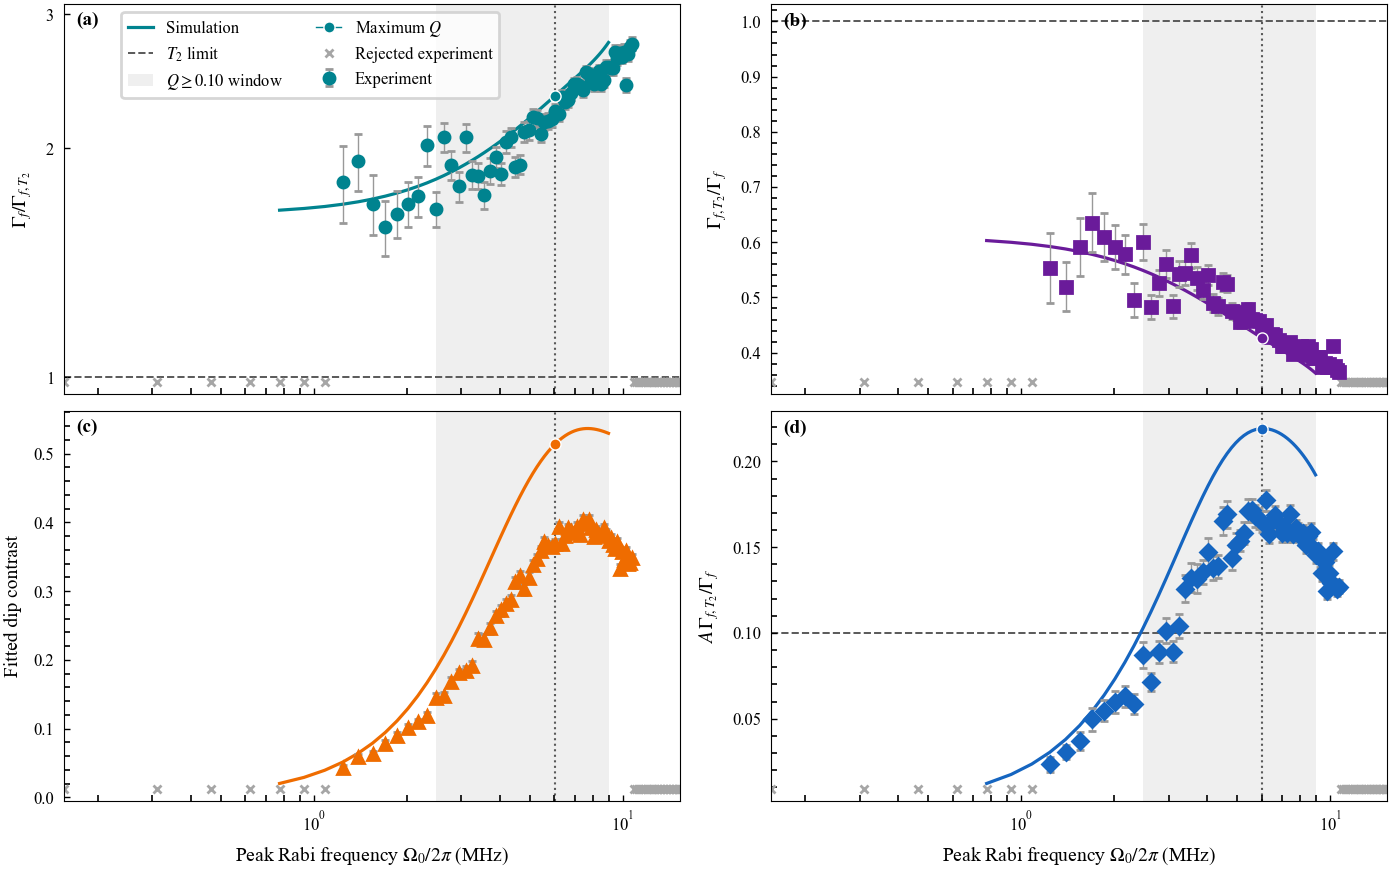

In [7]:
accepted = experiment_fits['valid'] & (experiment_fits['rabi_mhz'] > 0)
rejected = (~experiment_fits['valid']) & (experiment_fits['rabi_mhz'] > 0)
simulation_accepted = simulation_fits['valid'] & (simulation_fits['rabi_mhz'] > 0)
x = experiment_fits['rabi_mhz'][accepted]
S8_Q_THRESHOLD = 0.10
simulation_q = np.where(
    simulation_accepted,
    simulation_fits['contrast_weighted_resolution'],
    np.nan,
)
s8_window_indices = np.flatnonzero(
    np.isfinite(simulation_q) & (simulation_q >= S8_Q_THRESHOLD)
)
if s8_window_indices.size == 0:
    raise RuntimeError('The matched simulation has no Q >= 0.10 window.')
s8_window_runs = np.split(
    s8_window_indices, np.flatnonzero(np.diff(s8_window_indices) > 1) + 1
)
s8_q_windows = [
    (simulation_fits['rabi_mhz'][run[0]], simulation_fits['rabi_mhz'][run[-1]])
    for run in s8_window_runs
]
s8_simulation_indices = np.flatnonzero(np.isfinite(simulation_q))
s8_best_index = s8_simulation_indices[
    np.nanargmax(simulation_q[s8_simulation_indices])
]
s8_best_rabi_mhz = simulation_fits['rabi_mhz'][s8_best_index]
print(
    'S8 matched-simulation Q >= 0.10 window(s): '
    + ', '.join(f'{lo:.3f}--{hi:.3f} MHz' for lo, hi in s8_q_windows)
)
print(
    f'S8 maximum simulated Q at {s8_best_rabi_mhz:.3f} MHz: '
    f"Q={simulation_q[s8_best_index]:.3f}."
)

fig, axes = plt.subplots(2, 2, figsize=(7.0, 4.4), sharex=True, constrained_layout=True)

def add_metric(ax, key, error_key, color, marker, *, experiment_label=None, simulation_label=None):
    ax.errorbar(
        x, experiment_fits[key][accepted],
        yerr=experiment_fits[error_key][accepted],
        fmt=marker, color=color, ecolor='0.60', capsize=1.5,
        label=experiment_label, zorder=3,
    )
    simulated_metric = np.where(simulation_accepted, simulation_fits[key], np.nan)
    ax.plot(
        simulation_fits['rabi_mhz'], simulated_metric,
        color=color, lw=1.15, label=simulation_label, zorder=2,
    )

add_metric(
    axes[0, 0], 'fwhm_t2_units', 'fwhm_t2_units_error', '#00838f', 'o',
    experiment_label='Experiment', simulation_label='Simulation',
)
axes[0, 0].axhline(
    1, color='0.35', ls='--', lw=0.7, zorder=1, label=r'$T_2$ limit'
)
axes[0, 0].set_yscale('log')
axes[0, 0].set_ylim(0.95, 3.1)
axes[0, 0].set_yticks([1, 2, 3], labels=['1', '2', '3'])
axes[0, 0].set_ylabel(r'$\Gamma_f/\Gamma_{f,T_2}$')

add_metric(axes[0, 1], 'resolution_t2_units', 'resolution_t2_units_error', '#6a1b9a', 's')
axes[0, 1].axhline(1, color='0.35', ls='--', lw=0.7, zorder=1)
axes[0, 1].set_ylabel(r'$\Gamma_{f,T_2}/\Gamma_f$')

add_metric(axes[1, 0], 'contrast', 'contrast_error', '#ef6c00', '^')
axes[1, 0].set_ylabel('Fitted dip contrast')

add_metric(
    axes[1, 1], 'contrast_weighted_resolution',
    'contrast_weighted_resolution_error', '#1565c0', 'D',
)
axes[1, 1].set_ylabel(r'$A\,\Gamma_{f,T_2}/\Gamma_f$')
axes[1, 1].axhline(S8_Q_THRESHOLD, color='0.35', ls='--', lw=0.7, zorder=1)

s8_metric_styles = [
    ('fwhm_t2_units', '#00838f'),
    ('resolution_t2_units', '#6a1b9a'),
    ('contrast', '#ef6c00'),
    ('contrast_weighted_resolution', '#1565c0'),
]
plotted_rabi = experiment_fits['rabi_mhz'][experiment_fits['rabi_mhz'] > 0]
x_limits = (plotted_rabi.min(), plotted_rabi.max())
for label, ax, (metric_key, metric_color) in zip(
    ['(a)', '(b)', '(c)', '(d)'], axes.flat, s8_metric_styles
):
    ax.set_xscale('log')
    for window_index, (lower, upper) in enumerate(s8_q_windows):
        ax.axvspan(
            lower, upper, color='0.72', alpha=0.22, lw=0, zorder=0,
            label=r'$Q\geq0.10$ window'
            if label == '(a)' and window_index == 0 else None,
        )
    ax.axvline(s8_best_rabi_mhz, color='0.35', ls=':', lw=0.75, zorder=1)
    ax.plot(
        s8_best_rabi_mhz, simulation_fits[metric_key][s8_best_index],
        marker='o', ms=4.0, color=metric_color, mec='white', mew=0.5,
        zorder=4, label='Maximum $Q$' if label == '(a)' else None,
    )
    ax.plot(experiment_fits['rabi_mhz'][rejected], np.full(rejected.sum(), 0.03), 'x', color='0.65', ms=3, transform=ax.get_xaxis_transform(), label='Rejected experiment' if label == '(a)' else None)
    ax.set_xlim(*x_limits)
    ax.text(
        0.02, 0.98, label, transform=ax.transAxes, ha='left', va='top',
        fontweight='bold', zorder=10,
    )

axes[1, 0].set_xlabel(r'Peak Rabi frequency $\Omega_0/2\pi$ (MHz)')
axes[1, 1].set_xlabel(r'Peak Rabi frequency $\Omega_0/2\pi$ (MHz)')
axes[0, 0].legend(loc='upper left', bbox_to_anchor=(0.08, 1.0), ncol=2)

saved = save_figure(fig, '03_amplitude_robustness', variant=VARIANT, formats=('pdf', 'png', 'svg'), dpi=300)
saved

## Constant-pulse resolution--contrast window

The constant-drive reference is evaluated with the analytic steady-state Torrey tool used by the IPS FWHM plots. It uses the measured $T_1$ and effective $T_2$ values, and reports the cyclic-frequency FWHM $\Gamma_f$, inverse FWHM (resolution), population contrast, and their product over a restricted low-drive range. The shaded interval is the operational region where the contrast-weighted resolution satisfies $Q=A\,\Gamma_{f,T_2}/\Gamma_f\geq0.10$.


Low-drive linewidth: 43.873 kHz = 1.007365 Gamma_T2 (Gamma_T2=43.552 kHz).
Torrey constant-drive Q >= 0.10 window(s): 0.0045--0.0385 MHz
Maximum Q at 0.0116 MHz: W=1.732, R=0.577, A=0.333, Q=0.192.


[PosixPath('/Users/asafsolonnikov/Developer/amplitude-robust-spectroscopy/figures/paper/03_constant_pulse_metrics.pdf'),
 PosixPath('/Users/asafsolonnikov/Developer/amplitude-robust-spectroscopy/figures/paper/03_constant_pulse_metrics.png'),
 PosixPath('/Users/asafsolonnikov/Developer/amplitude-robust-spectroscopy/figures/paper/03_constant_pulse_metrics.svg')]

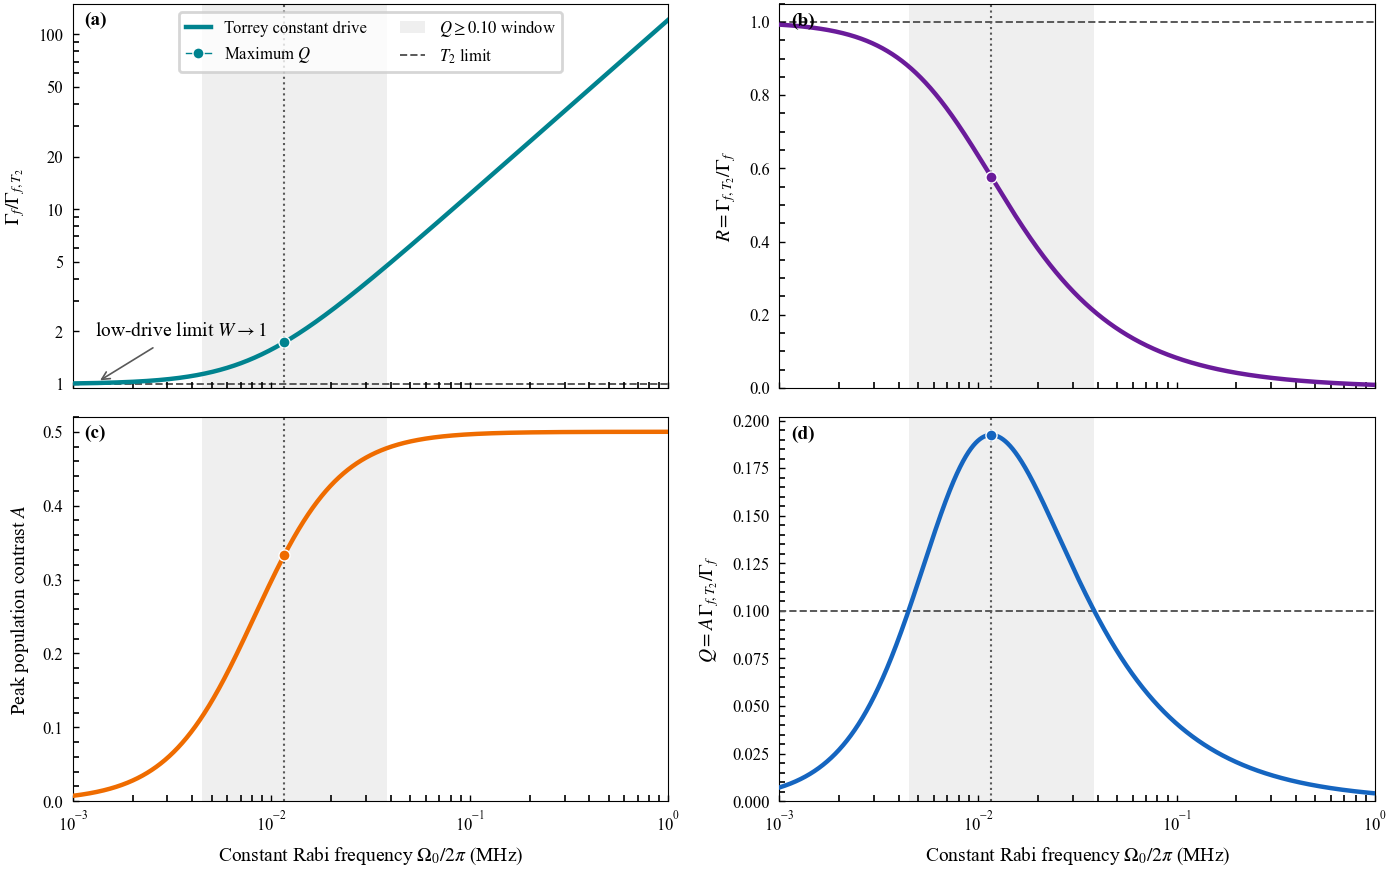

In [8]:
from echospec.experiments.torrey_resonance import (
    OptionsTorreyResonance,
    TorreyFwhmVsRabiExperiment,
)

CONSTANT_RABI_MHZ = np.geomspace(1e-3, 1.0, 10001)
TORREY_Q_THRESHOLD = 0.10
constant_params = Parameters(
    T1=T1_US * u.us,
    T_dephasing=TPHI_US * u.us,
)
constant_result = TorreyFwhmVsRabiExperiment(
    CONSTANT_RABI_MHZ * u.pi2 * u.MHz,
    constant_params,
    OptionsTorreyResonance(
        plot=False,
        save=False,
        plot_product=True,
        product_threshold=TORREY_Q_THRESHOLD,
    ),
).run()

constant_rabi_mhz = constant_result.rabi_frequencies_mhz
constant_resolution = constant_result.inverse_fwhm_t2_units
constant_fwhm_t2 = 1.0 / constant_resolution
constant_contrast = constant_result.snr
constant_product = constant_result.inverse_fwhm_snr_product
constant_t2_limit_khz = 1e3 / (np.pi * (constant_result.params.T2 / u.us))
assert np.isclose(constant_fwhm_t2[0], 1.0, rtol=1e-2)
useful_windows = constant_result.product_threshold_rabi_ranges_mhz
best_index = int(np.nanargmax(constant_product))
best_rabi_mhz = constant_rabi_mhz[best_index]

print(
    'Low-drive linewidth: '
    f'{constant_fwhm_t2[0] * constant_t2_limit_khz:.3f} kHz = '
    f'{constant_fwhm_t2[0]:.6f} Gamma_T2 '
    f'(Gamma_T2={constant_t2_limit_khz:.3f} kHz).'
)
print(
    'Torrey constant-drive Q >= '
    f'{TORREY_Q_THRESHOLD:.2f} window(s): '
    + ', '.join(f'{lo:.4f}--{hi:.4f} MHz' for lo, hi in useful_windows)
)
print(
    f'Maximum Q at {best_rabi_mhz:.4f} MHz: '
    f'W={constant_fwhm_t2[best_index]:.3f}, '
    f'R={constant_resolution[best_index]:.3f}, '
    f'A={constant_contrast[best_index]:.3f}, '
    f'Q={constant_product[best_index]:.3f}.'
)

fig_constant, constant_axes = plt.subplots(
    2, 2, figsize=(7.0, 4.4), sharex=True, constrained_layout=True
)
constant_metrics = [
    (constant_fwhm_t2, '#00838f', r'$\Gamma_f/\Gamma_{f,T_2}$'),
    (constant_resolution, '#6a1b9a', r'$R=\Gamma_{f,T_2}/\Gamma_f$'),
    (constant_contrast, '#ef6c00', r'Peak population contrast $A$'),
    (constant_product, '#1565c0', r'$Q=A\,\Gamma_{f,T_2}/\Gamma_f$'),
]

for panel, ax, (values, color, ylabel) in zip(
    ['(a)', '(b)', '(c)', '(d)'], constant_axes.flat, constant_metrics
):
    ax.plot(
        constant_rabi_mhz,
        values,
        color=color,
        lw=1.6,
        zorder=3,
        label='Torrey constant drive' if panel == '(a)' else None,
    )
    ax.plot(
        best_rabi_mhz,
        values[best_index],
        marker='o',
        ms=4.0,
        color=color,
        mec='white',
        mew=0.5,
        zorder=4,
        label='Maximum $Q$' if panel == '(a)' else None,
    )
    for window_index, (lower, upper) in enumerate(useful_windows):
        ax.axvspan(
            lower,
            upper,
            color='0.72',
            alpha=0.22,
            lw=0,
            label=r'$Q\geq0.10$ window'
            if panel == '(a)' and window_index == 0
            else None,
        )
    ax.axvline(best_rabi_mhz, color='0.35', ls=':', lw=0.75)
    ax.set_xscale('log')
    ax.set_xlim(CONSTANT_RABI_MHZ.min(), CONSTANT_RABI_MHZ.max())
    ax.set_ylabel(ylabel)
    ax.text(
        0.02,
        0.98,
        panel,
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontweight='bold',
    )

constant_axes[0, 0].axhline(
    1.0, color='0.35', ls='--', lw=0.7, zorder=1, label=r'$T_2$ limit'
)
constant_axes[0, 0].set_yscale('log')
constant_axes[0, 0].set_ylim(0.95, 150.0)
constant_axes[0, 0].set_yticks(
    [1, 2, 5, 10, 20, 50, 100],
    labels=['1', '2', '5', '10', '20', '50', '100'],
)
constant_axes[0, 0].annotate(
    r'low-drive limit $W\to1$',
    xy=(1.3e-3, 1.01),
    xytext=(1.3e-3, 1.8),
    ha='left',
    va='bottom',
    arrowprops=dict(arrowstyle='->', color='0.35', lw=0.6),
)
constant_axes[0, 1].axhline(1.0, color='0.35', ls='--', lw=0.7, zorder=1)
constant_axes[1, 1].axhline(
    TORREY_Q_THRESHOLD, color='0.35', ls='--', lw=0.7
)
constant_axes[0, 1].set_ylim(0, 1.05)
constant_axes[1, 0].set_ylim(0, 0.52)
constant_axes[1, 1].set_ylim(0, None)
constant_axes[1, 0].set_xlabel(
    r'Constant Rabi frequency $\Omega_0/2\pi$ (MHz)'
)
constant_axes[1, 1].set_xlabel(
    r'Constant Rabi frequency $\Omega_0/2\pi$ (MHz)'
)
constant_axes[0, 0].legend(loc='best', ncol=2)

saved_constant = save_figure(
    fig_constant,
    '03_constant_pulse_metrics',
    variant=VARIANT,
    formats=('pdf', 'png', 'svg'),
    dpi=300,
)
saved_constant


Main-figure echo simulation span: 0.001--15.316 MHz.
Finite low-amplitude extension fits: 60/60.
Root-Lorentzian accepted fits: 1/99; maximum accepted Q=0.224 at 4.796 MHz.


[PosixPath('/Users/asafsolonnikov/Developer/amplitude-robust-spectroscopy/figures/paper/04_main_resolution_comparison.pdf'),
 PosixPath('/Users/asafsolonnikov/Developer/amplitude-robust-spectroscopy/figures/paper/04_main_resolution_comparison.png'),
 PosixPath('/Users/asafsolonnikov/Developer/amplitude-robust-spectroscopy/figures/paper/04_main_resolution_comparison.svg')]

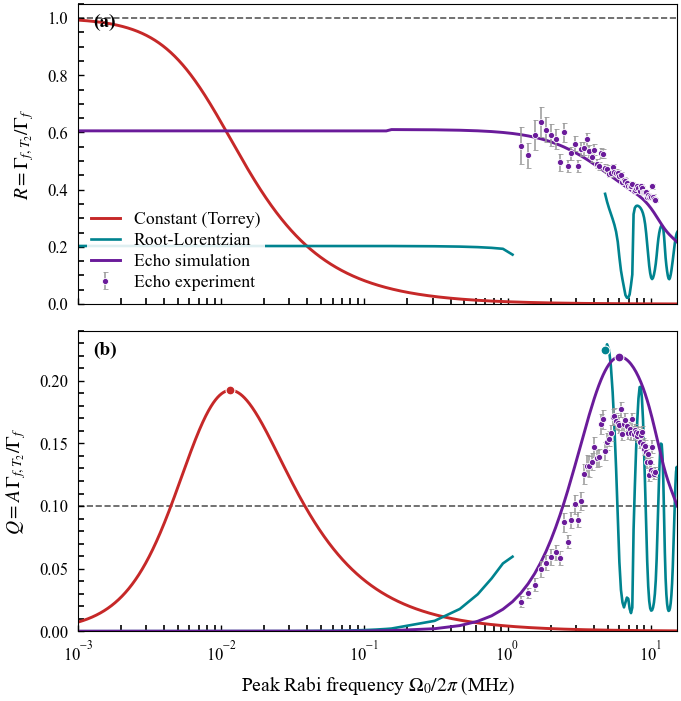

In [9]:
# Main-text Fig. 4: constant, root-Lorentzian, and echo comparison.
MAIN_X_MIN_MHZ = 1e-3
MAIN_X_MAX_MHZ = float(experiment_fits['rabi_mhz'][experiment_fits['rabi_mhz'] > 0].max())
MAIN_CONSTANT_RABI_MHZ = np.geomspace(MAIN_X_MIN_MHZ, MAIN_X_MAX_MHZ, 20_001)
main_constant_result = TorreyFwhmVsRabiExperiment(
    MAIN_CONSTANT_RABI_MHZ * u.pi2 * u.MHz,
    constant_params,
    OptionsTorreyResonance(
        plot=False,
        save=False,
        plot_product=True,
        product_threshold=TORREY_Q_THRESHOLD,
    ),
).run()
main_constant_rabi_mhz = main_constant_result.rabi_frequencies_mhz
main_constant_resolution = main_constant_result.inverse_fwhm_t2_units
main_constant_product = main_constant_result.inverse_fwhm_snr_product
main_constant_best_index = int(np.nanargmax(main_constant_product))

echo_color = '#6a1b9a'
lorentzian_color = '#00838f'
constant_color = '#c62828'
echo_experiment_mask = experiment_fits['valid'] & (experiment_fits['rabi_mhz'] > 0)
# Extend the matched echo model below the first nonzero acquisition amplitude.
# These extra points are simulation-only and use the identical detuning grid,
# pulse, coherence parameters, integrator, and fitting procedure.
first_acquired_rabi_mhz = float(simulation_fits['rabi_mhz'][simulation_fits['rabi_mhz'] > 0].min())
low_extension_rabi_mhz = np.geomspace(
    MAIN_X_MIN_MHZ, first_acquired_rabi_mhz, 60, endpoint=False
)
low_extension_state = simulate_bloch_grid(
    detuning_mhz,
    low_extension_rabi_mhz,
    pulse_length_us=acquisition['pulse_length_us'],
    cutoff=acquisition['cutoff'],
    echo=acquisition['echo'],
    T1_us=T1_US,
    Tphi_us=TPHI_US,
    num_time_steps=SIMULATION_TIME_STEPS,
)
lorentzian_state = simulate_bloch_grid(
    detuning_mhz,
    rabi_mhz,
    pulse_length_us=acquisition['pulse_length_us'],
    cutoff=acquisition['cutoff'],
    echo=False,
    T1_us=T1_US,
    Tphi_us=TPHI_US,
    num_time_steps=SIMULATION_TIME_STEPS,
)
low_extension_lorentzian_state = simulate_bloch_grid(
    detuning_mhz,
    low_extension_rabi_mhz,
    pulse_length_us=acquisition['pulse_length_us'],
    cutoff=acquisition['cutoff'],
    echo=False,
    T1_us=T1_US,
    Tphi_us=TPHI_US,
    num_time_steps=SIMULATION_TIME_STEPS,
)
def fit_low_signal_simulation_sweep(
    detuning_values, rabi_values, traces, *, peak=False
):
    resolution_values = np.full(len(rabi_values), np.nan)
    product_values = np.full(len(rabi_values), np.nan)
    for index, _ in enumerate(rabi_values):
        trace = np.asarray(traces[:, index], dtype=float)
        if peak:
            trace = -trace
        interior = gaussian_filter1d(
            trace[EDGE_POINTS:-EDGE_POINTS], SMOOTH_SIGMA_POINTS
        )
        edge_count = max(5, interior.size // 10)
        baseline = float(np.median(np.r_[
            interior[:edge_count], interior[-edge_count:]
        ]))
        raw_depth = baseline - float(np.min(interior))
        if not np.isfinite(raw_depth) or raw_depth <= 1e-12:
            continue
        # Width is scale-invariant.  Normalization prevents the nonlinear
        # fit from becoming ill-conditioned as contrast tends to zero.
        minimum = float(np.min(interior))
        normalized_trace = (trace - minimum) / raw_depth
        normalized_fit = fit_slice(detuning_values, normalized_trace)
        fwhm_mhz = normalized_fit.get('fwhm_mhz', np.nan)
        normalized_contrast = normalized_fit.get('contrast', np.nan)
        if not np.isfinite(fwhm_mhz) or fwhm_mhz <= 0:
            continue
        resolution_values[index] = T2_LIMIT_FWHM_MHZ / fwhm_mhz
        physical_contrast = normalized_contrast * raw_depth
        product_values[index] = physical_contrast * resolution_values[index]
    return {
        'rabi_mhz': np.asarray(rabi_values, dtype=float),
        'resolution_t2_units': resolution_values,
        'contrast_weighted_resolution': product_values,
    }

low_extension_fits = fit_low_signal_simulation_sweep(
    detuning_mhz, low_extension_rabi_mhz, low_extension_state
)
lorentzian_fits = fit_metric_sweep(
    detuning_mhz, rabi_mhz, lorentzian_state, peak=True
)
low_extension_lorentzian_fits = fit_low_signal_simulation_sweep(
    detuning_mhz, low_extension_rabi_mhz,
    low_extension_lorentzian_state, peak=True,
)
acquired_simulation_positive = simulation_fits['rabi_mhz'] > 0
echo_simulation_rabi_mhz = np.concatenate([
    low_extension_fits['rabi_mhz'],
    simulation_fits['rabi_mhz'][acquired_simulation_positive],
])
echo_simulation_resolution = np.concatenate([
    low_extension_fits['resolution_t2_units'],
    simulation_fits['resolution_t2_units'][acquired_simulation_positive],
])
echo_simulation_product = np.concatenate([
    low_extension_fits['contrast_weighted_resolution'],
    simulation_fits['contrast_weighted_resolution'][acquired_simulation_positive],
])
lorentzian_positive = lorentzian_fits['rabi_mhz'] > 0
lorentzian_simulation_rabi_mhz = np.concatenate([
    low_extension_lorentzian_fits['rabi_mhz'],
    lorentzian_fits['rabi_mhz'][lorentzian_positive],
])
lorentzian_simulation_resolution = np.concatenate([
    low_extension_lorentzian_fits['resolution_t2_units'],
    lorentzian_fits['resolution_t2_units'][lorentzian_positive],
])
lorentzian_simulation_product = np.concatenate([
    low_extension_lorentzian_fits['contrast_weighted_resolution'],
    lorentzian_fits['contrast_weighted_resolution'][lorentzian_positive],
])
echo_simulation_display_mask = (
    np.isfinite(echo_simulation_resolution)
    & np.isfinite(echo_simulation_product)
)
echo_simulation_resolution = np.where(
    echo_simulation_display_mask, echo_simulation_resolution, np.nan
)
echo_simulation_product = np.where(
    echo_simulation_display_mask, echo_simulation_product, np.nan
)
lorentzian_simulation_display_mask = (
    np.isfinite(lorentzian_simulation_resolution)
    & np.isfinite(lorentzian_simulation_product)
)
lorentzian_simulation_resolution = np.where(
    lorentzian_simulation_display_mask,
    lorentzian_simulation_resolution, np.nan,
)
lorentzian_simulation_product = np.where(
    lorentzian_simulation_display_mask,
    lorentzian_simulation_product, np.nan,
)
lorentzian_accepted = lorentzian_fits['valid'] & lorentzian_positive
lorentzian_q = np.where(
    lorentzian_accepted,
    lorentzian_fits['contrast_weighted_resolution'], np.nan,
)
lorentzian_accepted_indices = np.flatnonzero(np.isfinite(lorentzian_q))
if lorentzian_accepted_indices.size == 0:
    raise RuntimeError('The root-Lorentzian simulation has no accepted fits.')
lorentzian_best_index = lorentzian_accepted_indices[
    np.nanargmax(lorentzian_q[lorentzian_accepted_indices])
]
print(
    'Main-figure echo simulation span: '
    f'{echo_simulation_rabi_mhz.min():.4g}--{echo_simulation_rabi_mhz.max():.3f} MHz.'
)
print(
    'Finite low-amplitude extension fits: '
    f"{np.isfinite(low_extension_fits['resolution_t2_units']).sum()}"
    f'/{len(low_extension_rabi_mhz)}.'
)
print(
    'Root-Lorentzian accepted fits: '
    f"{lorentzian_accepted.sum()}/{lorentzian_positive.sum()}; "
    f"maximum accepted Q={lorentzian_q[lorentzian_best_index]:.3f} "
    f"at {lorentzian_fits['rabi_mhz'][lorentzian_best_index]:.3f} MHz."
)

fig_main, main_axes = plt.subplots(
    2, 1, figsize=(3.45, 3.55), sharex=True, constrained_layout=True
)
main_metrics = [
    (
        'resolution_t2_units',
        'resolution_t2_units_error',
        echo_simulation_resolution,
        lorentzian_simulation_resolution,
        main_constant_resolution,
        r'$R=\Gamma_{f,T_2}/\Gamma_f$',
    ),
    (
        'contrast_weighted_resolution',
        'contrast_weighted_resolution_error',
        echo_simulation_product,
        lorentzian_simulation_product,
        main_constant_product,
        r'$Q=A\,\Gamma_{f,T_2}/\Gamma_f$',
    ),
]

for panel, ax, (
    metric_key, error_key, echo_simulated, lorentzian_simulated,
    constant_values, ylabel,
) in zip(
    ['(a)', '(b)'], main_axes, main_metrics
):
    ax.plot(
        main_constant_rabi_mhz, constant_values,
        color=constant_color, lw=1.05, label='Constant (Torrey)', zorder=2,
    )
    ax.plot(
        lorentzian_simulation_rabi_mhz, lorentzian_simulated,
        color=lorentzian_color, lw=0.95,
        label='Root-Lorentzian', zorder=2,
    )
    ax.plot(
        echo_simulation_rabi_mhz, echo_simulated,
        color=echo_color, lw=1.05, label='Echo simulation', zorder=2,
    )
    ax.errorbar(
        experiment_fits['rabi_mhz'][echo_experiment_mask],
        experiment_fits[metric_key][echo_experiment_mask],
        yerr=experiment_fits[error_key][echo_experiment_mask],
        fmt='o', ms=2.2, color=echo_color, ecolor='0.60',
        mec='white', mew=0.30, capsize=0.9, elinewidth=0.55, capthick=0.55,
        label='Echo experiment', zorder=3,
    )
    ax.set_xscale('log')
    ax.set_xlim(MAIN_X_MIN_MHZ, MAIN_X_MAX_MHZ)
    ax.set_ylabel(ylabel)
    ax.text(
        0.025, 0.965, panel, transform=ax.transAxes,
        ha='left', va='top', fontweight='bold',
    )

main_axes[0].axhline(
    1.0, color='0.35', ls='--', lw=0.6, zorder=1,
    label=r'$T_2$-limited resolution',
)
main_axes[0].set_ylim(0.0, 1.05)
main_axes[1].axhline(
    TORREY_Q_THRESHOLD, color='0.35', ls='--', lw=0.6, zorder=1
)
main_axes[1].plot(
    main_constant_rabi_mhz[main_constant_best_index],
    main_constant_product[main_constant_best_index],
    marker='o', ms=3.2, color=constant_color, mec='white', mew=0.4, zorder=4,
)
main_axes[1].plot(
    lorentzian_fits['rabi_mhz'][lorentzian_best_index],
    lorentzian_q[lorentzian_best_index],
    marker='o', ms=3.2, color=lorentzian_color,
    mec='white', mew=0.4, zorder=4,
)
main_axes[1].plot(
    s8_best_rabi_mhz, simulation_q[s8_best_index],
    marker='o', ms=3.2, color=echo_color, mec='white', mew=0.4, zorder=4,
)
main_axes[1].set_ylim(0.0, 0.24)
main_axes[1].set_xlabel(r'Peak Rabi frequency $\Omega_0/2\pi$ (MHz)')
handles, labels = main_axes[0].get_legend_handles_labels()
legend_order = [labels.index(name) for name in [
    'Constant (Torrey)', 'Root-Lorentzian',
    'Echo simulation', 'Echo experiment',
]]
main_axes[0].legend(
    [handles[index] for index in legend_order],
    [labels[index] for index in legend_order],
    loc='lower left', frameon=True, framealpha=0.88, edgecolor='none',
    fontsize=6.4, handlelength=1.6, borderpad=0.25, labelspacing=0.25,
)

saved_main = save_figure(
    fig_main,
    '04_main_resolution_comparison',
    variant=VARIANT,
    formats=('pdf', 'png', 'svg'),
    dpi=300,
)
saved_main


### Statistical caveat

The normalization uses the conservative measurement-linked reference $T_{2,\mathrm{eff}}=T_2^*=7.31~\mu\mathrm{s}$, so $\Gamma_{f,T_2}=1/(\pi T_{2,\mathrm{eff}})=43.5~\mathrm{kHz}$. The solid simulation curves use $T_1=51.24~\mu\mathrm{s}$ and $T_\phi=7.87~\mu\mathrm{s}$ in the same two-level Lindblad model, with the recorded 10-$\mu\mathrm{s}$ root-Lorentzian waveform, $c=0.005$, echo phase inversion, and calibrated physical peak-Rabi grid. Panel (a) reports cyclic-frequency FWHM in units of this limit, panel (b) reports its reciprocal as normalized resolution, and panel (d) multiplies that resolution by the fitted dip contrast. Experimental error bars are propagated from the local least-squares covariance matrix after smoothing, including the fitted contrast-width covariance in panel (d). They are fit diagnostics, not repeated-experiment RMSE values or per-shot Cramér--Rao bounds. The deterministic simulation curves carry no sampling-error bars.